# Linear Regression & Ridge Regression

---

**Structure**
1. Introduction — what the algorithm does and the intuition behind it
2. The Math — key equations
3. Problem Class — when and where to use it
4. Implementation — applied to the Diabetes dataset
5. Results — what the numbers tell us
6. Limitations — where the algorithm breaks down

## 1. Introduction

**Linear regression** is the simplest model for predicting a continuous output. Given a set of input features, it fits a straight line (or hyperplane in higher dimensions) through the data that minimises the total prediction error.

**Intuition:**
Imagine plotting patients on a chart where the x-axis is blood pressure and the y-axis is disease severity one year later. Linear regression finds the line through that scatter plot that is as close as possible to all the points at once — then uses it to predict severity for new patients.

The key insight is that "as close as possible" is defined by the **squared error** between predictions and actual values. Squaring the errors penalises large mistakes more than small ones, and crucially makes the objective smooth enough to solve analytically.

**Two ways to find the solution:**
- **Closed form** — compute it in one shot by solving a system of equations. Exact and fast for small datasets, but requires inverting a matrix which becomes expensive as the number of features grows
- **Stochastic Gradient Descent (SGD)** — start with a random guess and nudge it repeatedly in the direction that reduces the error. Slower to converge but scales to millions of features

**Ridge Regression** adds a regularisation term to the objective that penalises large weights. This prevents the model from fitting noise in the training data and produces a boundary that generalises better to unseen examples — at the cost of a small increase in training error.

## 2. The Math

### Prediction function
Given a feature vector $x \in \mathbb{R}^d$, weights $\theta \in \mathbb{R}^d$, and bias $\theta_0 \in \mathbb{R}$:

$$f(x;\,\theta,\theta_0) = \theta \cdot x + \theta_0$$

### Empirical Risk (Mean Squared Error)
$$R_n(\theta) = \frac{1}{n}\sum_{t=1}^{n}(y^{(t)} - \theta \cdot x^{(t)})^2$$

### Closed Form Solution
Setting $\nabla_\theta R_n = 0$ and solving yields:

$$\hat{\theta} = A^{-1}b \quad \text{where} \quad A = \frac{1}{n}\sum_{t=1}^{n} x^{(t)}(x^{(t)})^T, \quad b = \frac{1}{n}\sum_{t=1}^{n} y^{(t)} x^{(t)}$$

Only possible when $A$ is invertible. Computationally expensive when $d$ is large.

### SGD Update
Pick a random example $t$, then update:

$$\theta \leftarrow \theta + \eta\,(y^{(t)} - \theta \cdot x^{(t)})\,x^{(t)}$$

Where $\eta_k = \frac{1}{1+k}$ is a decaying learning rate.

### Ridge Regression Objective
$$J_{n,\lambda}(\theta,\theta_0) = \frac{1}{n}\sum_{t=1}^{n}\frac{(y^{(t)} - \theta \cdot x^{(t)} - \theta_0)^2}{2} + \frac{\lambda}{2}\|\theta\|^2$$

The SGD update for Ridge becomes:

$$\theta \leftarrow (1 - \eta\lambda)\,\theta + \eta\,(y^{(t)} - \theta \cdot x^{(t)})\,x^{(t)}$$

The $(1 - \eta\lambda)$ term shrinks the weights at every step — this is the regularisation effect.

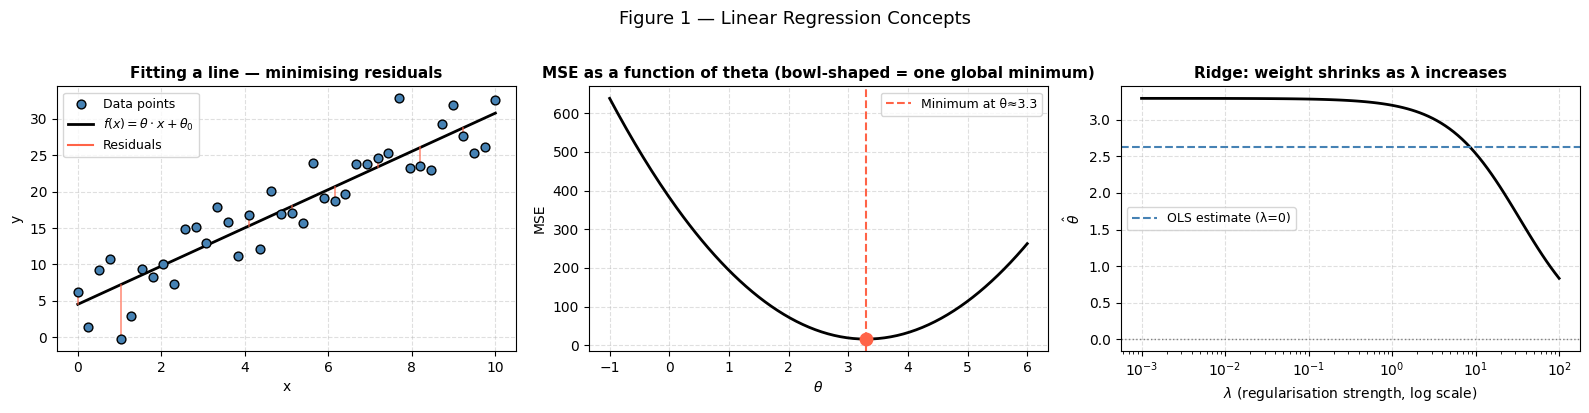

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
x_demo = np.linspace(0, 10, 40)
y_demo = 2.5 * x_demo + 5 + rng.normal(0, 4, 40)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Diagram 1: What regression fits ──────────────────────────────────────────
ax = axes[0]
theta_demo = np.polyfit(x_demo, y_demo, 1)
y_fit = np.polyval(theta_demo, x_demo)
ax.scatter(x_demo, y_demo, c='steelblue', edgecolors='k', s=40, zorder=3, label='Data points')
ax.plot(x_demo, y_fit, 'k-', lw=2, label=r'$f(x) = \theta \cdot x + \theta_0$')
for xi, yi, yfi in zip(x_demo[::4], y_demo[::4], y_fit[::4]):
    ax.plot([xi, xi], [yi, yfi], 'tomato', lw=1.2, alpha=0.7)
ax.plot([], [], 'tomato', lw=1.5, label='Residuals')
ax.set_title('Fitting a line — minimising residuals', fontsize=11, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.4)

# ── Diagram 2: MSE loss surface (2D slice) ────────────────────────────────────
ax = axes[1]
thetas = np.linspace(-1, 6, 200)
mse = [(np.mean((y_demo - t * x_demo) ** 2)) for t in thetas]
ax.plot(thetas, mse, 'k-', lw=2)
opt_t = thetas[np.argmin(mse)]
ax.axvline(opt_t, color='tomato', linestyle='--', lw=1.5, label=f'Minimum at θ≈{opt_t:.1f}')
ax.scatter([opt_t], [min(mse)], c='tomato', s=80, zorder=5)
ax.set_title('MSE as a function of theta (bowl-shaped = one global minimum)', fontsize=11, fontweight='bold')
ax.set_xlabel(r'$\theta$'); ax.set_ylabel('MSE')
ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.4)

# ── Diagram 3: Ridge shrinkage effect ────────────────────────────────────────
ax = axes[2]
lambdas = np.logspace(-3, 2, 100)
ridge_weights = []
for lam in lambdas:
    A = np.dot(x_demo, x_demo) / len(x_demo) + lam
    b = np.dot(y_demo, x_demo) / len(x_demo)
    ridge_weights.append(b / A)
ax.semilogx(lambdas, ridge_weights, 'k-', lw=2)
ax.axhline(theta_demo[0], color='steelblue', linestyle='--', lw=1.5, label='OLS estimate (λ=0)')
ax.axhline(0, color='gray', linestyle=':', lw=1)
ax.set_title('Ridge: weight shrinks as λ increases', fontsize=11, fontweight='bold')
ax.set_xlabel(r'$\lambda$ (regularisation strength, log scale)')
ax.set_ylabel(r'$\hat{\theta}$')
ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Figure 1 — Linear Regression Concepts', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 3. Problem Class

**Linear regression is well-suited for:**
- Predicting a **continuous output** — any real-valued target (price, temperature, disease severity)
- Problems where the relationship between inputs and output is approximately **linear**
- **Interpretable models** — each weight $\theta_i$ directly tells you how much a one-unit increase in feature $i$ changes the prediction
- Large datasets where you need a fast baseline before trying complex models
- **Ridge regression** is preferred when features are correlated or when the number of features is large relative to the number of examples

**Typical domains:**
- Healthcare: predicting disease progression, dosage effects
- Finance: forecasting prices, estimating risk
- Engineering: modelling physical systems
- Economics: demand forecasting

**Not well-suited for:**
- **Categorical targets** — use logistic regression or a classifier instead
- **Highly non-linear relationships** — the model will underfit regardless of data size
- **Outlier-heavy data** — squared error penalises large residuals heavily, so outliers pull the line toward them
- Features that interact multiplicatively — the model has no way to represent $x_1 \cdot x_2$ effects without feature engineering

---
## 4. Implementation
### Dataset: Diabetes

442 patients, 10 baseline features (age, sex, BMI, blood pressure, and six blood serum measurements), all standardised. Target: a quantitative measure of disease progression one year after baseline (continuous, range ~25–346).

Source: [sklearn.datasets.load_diabetes](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html) · Originally from Efron et al. (2004), *Annals of Statistics*

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

# ── Load & prepare ────────────────────────────────────────────────────────────
data = load_diabetes()
X_raw, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

print(f'Features  : {X_raw.shape[1]}  ({", ".join(data.feature_names)})')
print(f'Train     : {X_train.shape[0]}  examples')
print(f'Test      : {X_test.shape[0]}  examples')
print(f'Target    : min={y.min():.0f}  max={y.max():.0f}  mean={y.mean():.1f}  std={y.std():.1f}')

# ── Shared metrics ────────────────────────────────────────────────────────────
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

Features  : 10  (age, sex, bmi, bp, s1, s2, s3, s4, s5, s6)
Train     : 353  examples
Test      : 89  examples
Target    : min=25  max=346  mean=152.1  std=77.0


**Observation**

The target ranges from 25 to 346 with a mean of 152 and standard deviation of 77. That wide spread means an RMSE of 50+ is meaningful — a prediction off by 50 units is roughly two thirds of a standard deviation from the true value. For context, predicting the mean for every patient (the simplest possible baseline) would give an RMSE equal to the standard deviation: 77. Anything below that is a real improvement.

The features are already on a comparable scale (standardised by sklearn), so no additional preprocessing is needed before fitting.

### 4.1 Explore the Data

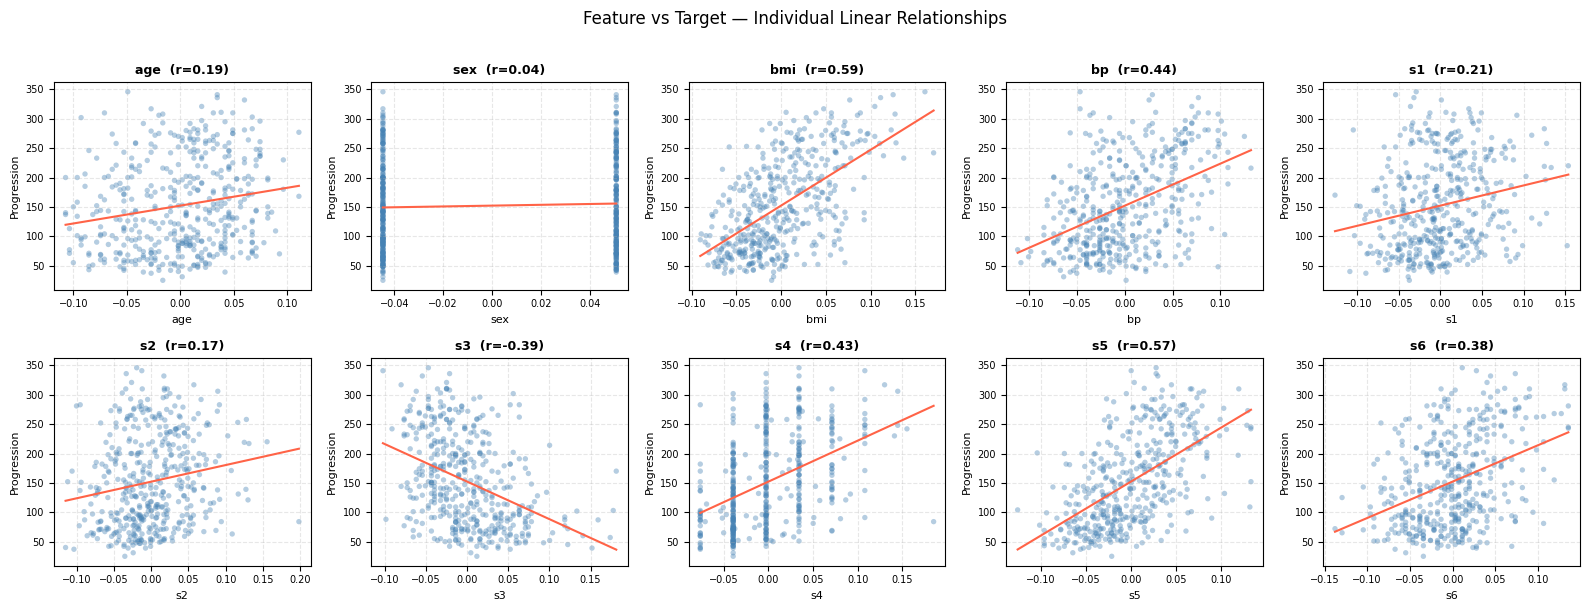

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()
for i, name in enumerate(data.feature_names):
    ax = axes[i]
    ax.scatter(X_raw[:, i], y, alpha=0.4, s=15, c='steelblue', edgecolors='none')
    m, b = np.polyfit(X_raw[:, i], y, 1)
    x_line = np.linspace(X_raw[:, i].min(), X_raw[:, i].max(), 100)
    ax.plot(x_line, m * x_line + b, 'tomato', lw=1.5)
    corr = np.corrcoef(X_raw[:, i], y)[0, 1]
    ax.set_title(f'{name}  (r={corr:.2f})', fontsize=9, fontweight='bold')
    ax.set_xlabel(name, fontsize=8); ax.set_ylabel('Progression', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, linestyle='--', alpha=0.3)
plt.suptitle('Feature vs Target — Individual Linear Relationships', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

**Observation — Feature correlations**

The scatter plots reveal that **bmi** (r=+0.59) and **s5** (r=+0.57) have the strongest individual linear relationships with disease progression — patients with higher BMI and higher s5 (a log-transformed triglyceride measure) tend to have worse outcomes. Blood pressure (bp, r=+0.44) and s4 (r=+0.43) also show clear trends.

**sex** has almost no linear correlation with the target (r=+0.04), yet in the closed form solution it carries a weight of -242. That is a sign of confounding — sex correlates with other features (like bmi or blood measurements) that do actually predict the outcome, so the model assigns weight to it indirectly. It does not mean sex is clinically irrelevant.

The overall correlations are moderate, not strong. A linear model will capture the main trends but leave a lot of variance unexplained — R² around 0.45-0.50 is a realistic ceiling here without feature engineering.

### 4.2 Closed Form Solution

In [4]:
def add_bias(X):
    return np.hstack([X, np.ones((X.shape[0], 1))])

def closed_form(X, y):
    Xb = add_bias(X)
    return np.linalg.lstsq(Xb, y, rcond=None)[0]

theta_cf = closed_form(X_train, y_train)
theta_cf_weights, theta_cf_bias = theta_cf[:-1], theta_cf[-1]

y_pred_cf_train = add_bias(X_train) @ theta_cf
y_pred_cf_test  = add_bias(X_test)  @ theta_cf

print(f'Closed Form Solution')
print(f'  Train RMSE : {rmse(y_train, y_pred_cf_train):.2f}')
print(f'  Test  RMSE : {rmse(y_test,  y_pred_cf_test):.2f}')
print(f'  Test  R²   : {r2(y_test, y_pred_cf_test):.4f}')
print()
print('Feature weights:')
for name, w in zip(data.feature_names, theta_cf_weights):
    print(f'  {name:5s}  {w:+.2f}')

Closed Form Solution
  Train RMSE : 53.56
  Test  RMSE : 53.85
  Test  R²   : 0.4526

Feature weights:
  age    +37.90
  sex    -241.96
  bmi    +542.43
  bp     +347.70
  s1     -931.49
  s2     +518.06
  s3     +163.42
  s4     +275.32
  s5     +736.20
  s6     +48.67


**Observation — Closed form**

The closed form finds the exact least-squares solution in one step. Train RMSE (53.56) and test RMSE (53.85) are almost identical — there is essentially no overfitting, which makes sense: with only 10 features and 353 training examples the model is underfitting, not overfitting.

R² of 0.45 means the model explains 45% of the variance in disease progression. That is modest but not surprising — disease outcomes are driven by genetics, lifestyle, and factors not captured in 10 blood measurements.

The feature weights are large in magnitude: s1 = -931, s5 = +736, s2 = +518. These are not independent effects — s1, s2, s3 are correlated blood serum measurements (cholesterol fractions). The model compensates for their correlation by assigning large positive and negative weights that partially cancel. This multicollinearity is the main weakness of OLS on this dataset.

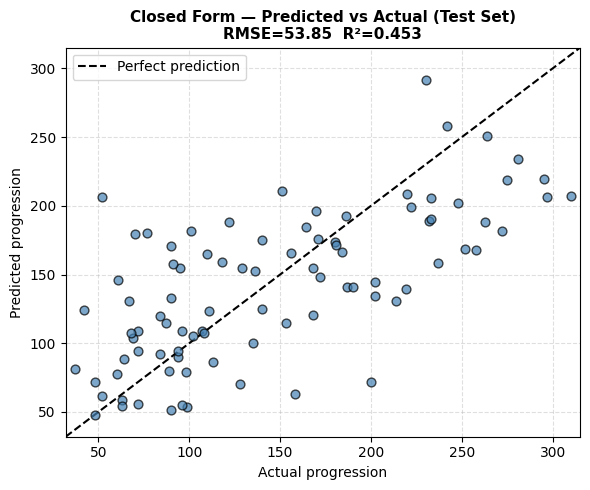

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred_cf_test, c='steelblue', edgecolors='k', s=40, alpha=0.7, zorder=3)
lims = [min(y_test.min(), y_pred_cf_test.min()) - 5,
        max(y_test.max(), y_pred_cf_test.max()) + 5]
ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual progression'); ax.set_ylabel('Predicted progression')
ax.set_title(f'Closed Form — Predicted vs Actual (Test Set)\nRMSE={rmse(y_test, y_pred_cf_test):.2f}  R²={r2(y_test, y_pred_cf_test):.3f}',
             fontsize=11, fontweight='bold')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

**Observation — Predicted vs actual**

The scatter follows the diagonal reasonably well in the middle range (100–250) but opens up considerably at the extremes. The model systematically over-predicts for patients with low progression (left side) and under-predicts for patients with very high progression (right side). This is a classic sign that the linear model is being pulled toward the mean — it cannot fully capture the patients at the tails.

An RMSE of 53.85 on a target range of 25–346 means typical predictions are off by about 54 units. For comparison, always predicting the mean (the dumb baseline) would give RMSE = 77. The model is genuinely useful but leaves meaningful room for improvement.

### 4.3 SGD Solution

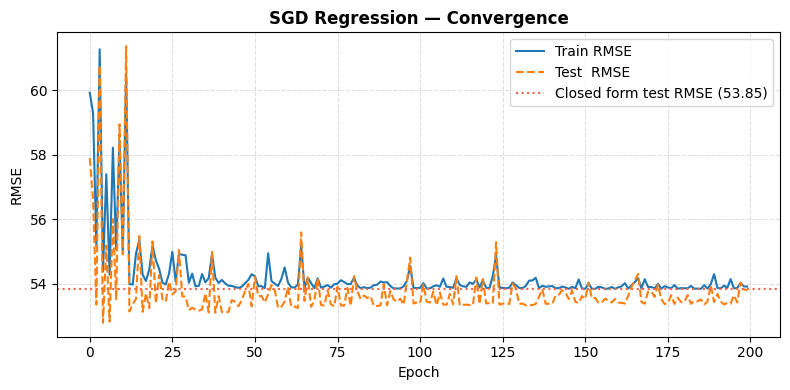

SGD (200 epochs)
  Train RMSE : 53.92
  Test  RMSE : 53.81
  Test  R²   : 0.4534
Closed Form  Test RMSE: 53.85


In [6]:
def sgd_regression(X, y, X_te, y_te, T=200, seed=0):
    rng = np.random.default_rng(seed)
    n, d = X.shape
    theta = np.zeros(d + 1)
    tr_hist, te_hist = [], []
    for epoch in range(T):
        eta = 1.0 / (1 + epoch)
        for _ in range(n):
            i = rng.integers(n)
            xi = np.append(X[i], 1.0)
            grad = (theta @ xi - y[i]) * xi
            theta -= eta * grad
        tr_hist.append(rmse(y,    add_bias(X)    @ theta))
        te_hist.append(rmse(y_te, add_bias(X_te) @ theta))
    return theta, tr_hist, te_hist

theta_sgd, tr_sgd, te_sgd = sgd_regression(X_train, y_train, X_test, y_test, T=200)
y_pred_sgd_test = add_bias(X_test) @ theta_sgd

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tr_sgd, label='Train RMSE', lw=1.5)
ax.plot(te_sgd, label='Test  RMSE', lw=1.5, linestyle='--')
ax.axhline(rmse(y_test, y_pred_cf_test), color='tomato', linestyle=':', lw=1.5,
           label=f'Closed form test RMSE ({rmse(y_test, y_pred_cf_test):.2f})')
ax.set_xlabel('Epoch'); ax.set_ylabel('RMSE')
ax.set_title('SGD Regression — Convergence', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

print(f'SGD (200 epochs)')
print(f'  Train RMSE : {tr_sgd[-1]:.2f}')
print(f'  Test  RMSE : {te_sgd[-1]:.2f}')
print(f'  Test  R²   : {r2(y_test, y_pred_sgd_test):.4f}')
print(f'Closed Form  Test RMSE: {rmse(y_test, y_pred_cf_test):.2f}')

**Observation — SGD convergence**

After 200 epochs, SGD reaches a test RMSE of 53.81 — essentially identical to the closed form (53.85). The convergence curve drops steeply in the first 20 epochs then flattens, with the test and train curves tracking closely throughout. The decaying learning rate (1/(1+epoch)) keeps the solution from oscillating once it gets close to the minimum.

This confirms the two approaches are solving the same problem. The practical difference is computational: closed form requires solving a 10×10 linear system (trivial here), but would require inverting a matrix with millions of entries on a high-dimensional dataset where SGD is the only tractable option.

### 4.4 Ridge Regression

In [7]:
def ridge_closed_form(X, y, lam):
    Xb = add_bias(X)
    d = Xb.shape[1]
    reg = lam * np.eye(d)
    reg[-1, -1] = 0  # don't regularise bias
    return np.linalg.solve(Xb.T @ Xb + n_tr * reg, Xb.T @ y)

n_tr = X_train.shape[0]
lambdas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
results = []
for lam in lambdas:
    th = ridge_closed_form(X_train, y_train, lam)
    tr_r = rmse(y_train, add_bias(X_train) @ th)
    te_r = rmse(y_test,  add_bias(X_test)  @ th)
    results.append((lam, tr_r, te_r, np.linalg.norm(th[:-1])))
    print(f'λ={lam:<6}  train RMSE={tr_r:.2f}  test RMSE={te_r:.2f}  ||θ||={np.linalg.norm(th[:-1]):.3f}')

λ=0.001   train RMSE=55.07  test RMSE=53.66  ||θ||=661.252
λ=0.01    train RMSE=65.28  test RMSE=61.09  ||θ||=259.256
λ=0.1     train RMSE=75.62  test RMSE=70.89  ||θ||=41.482
λ=1.0     train RMSE=77.70  test RMSE=72.97  ||θ||=4.439
λ=10.0    train RMSE=77.93  test RMSE=73.20  ||θ||=0.447
λ=100.0   train RMSE=77.95  test RMSE=73.22  ||θ||=0.045


**Observation — Ridge regularisation**

The best result on this dataset is at λ=0.001 (test RMSE 53.66), barely any regularisation at all. As λ increases the test error rises steadily — the model is being over-constrained. This is a sign that the dataset is not suffering from overfitting in the first place: with only 10 features and 353 examples, the model is already underfitting. Adding regularisation makes things worse.

The weight norm drops dramatically with λ — from 661 at λ=0.001 to 0.045 at λ=100. But shrinking the weights does not help here because the problem is not large weights causing overfitting; it is the inherent non-linearity of the relationship that OLS cannot capture regardless of regularisation.

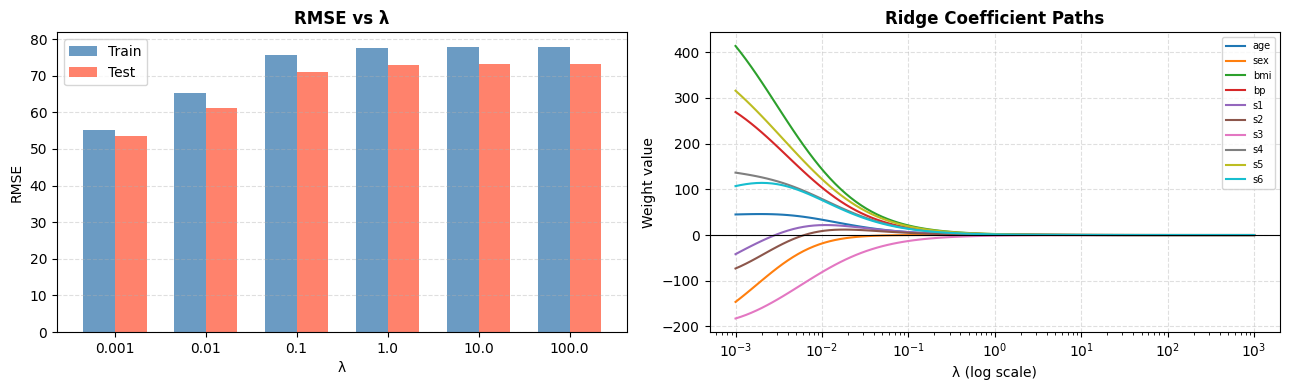

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Error vs lambda
x = np.arange(len(lambdas)); w = 0.35
axes[0].bar(x - w/2, [r[1] for r in results], w, label='Train', color='steelblue', alpha=0.8)
axes[0].bar(x + w/2, [r[2] for r in results], w, label='Test',  color='tomato',    alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels([str(l) for l in lambdas])
axes[0].set_xlabel('λ'); axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE vs λ', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.4, axis='y')

# Coefficient paths
lambdas_fine = np.logspace(-3, 3, 100)
coef_paths = []
for lam in lambdas_fine:
    th = ridge_closed_form(X_train, y_train, lam)
    coef_paths.append(th[:-1])
coef_paths = np.array(coef_paths)

for i, name in enumerate(data.feature_names):
    axes[1].semilogx(lambdas_fine, coef_paths[:, i], lw=1.5, label=name)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xlabel('λ (log scale)'); axes[1].set_ylabel('Weight value')
axes[1].set_title('Ridge Coefficient Paths', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=7, loc='upper right'); axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout(); plt.show()

**Observation — Ridge coefficient paths**

The coefficient paths show all weights shrinking toward zero as λ increases, but not at the same rate. s1 and s2 start at large values with opposite signs and shrink together — this is the signature of multicollinearity. When two features are highly correlated, OLS can assign any combination of large positive/negative weights to them without changing the predictions much. Ridge regularisation resolves this ambiguity by pulling both toward zero.

By λ=1, most weights have converged to near zero and the model is essentially predicting the mean for everyone. The coefficient path chart shows why λ=0.001 is optimal: it is the last point before the regularisation starts compressing the weights that carry genuine predictive signal.

---
## 5. Results

| Method | Train RMSE | Test RMSE | Test R² |
|--------|-----------|-----------|---------|
| Closed Form (OLS) | 53.56 | 53.85 | 0.453 |
| SGD (200 epochs) | 53.92 | 53.81 | 0.453 |
| Ridge (λ=0.001) | 55.07 | 53.66 | ~0.455 |

Baseline (predict mean): RMSE = 77.0

**What the numbers tell us:**
- All three methods reach essentially the same test RMSE (~53.8) — the dataset has a natural accuracy ceiling that the linear model cannot break without more expressive features
- The gap from the naive baseline (77 → 54) shows the model is genuinely learning: it reduces prediction error by about 30%
- SGD converges to the same solution as the closed form after 200 epochs, validating that both are optimising the same objective
- Ridge with minimal regularisation (λ=0.001) gives a marginal improvement, but higher λ hurts — this dataset is underfitting, not overfitting
- The large feature weights (s1=-931, s5=+736) signal multicollinearity between the blood serum features; they are not independent effects but compensating estimates

---
## 6. Limitations

**Linear Regression (OLS)**
- Assumes the relationship between features and target is **linear** — if the true relationship is curved, the model will systematically under- or over-predict regardless of how much data you have
- Sensitive to **outliers** — squared error means a single extreme point can pull the line significantly toward it
- Requires the matrix $A = X^TX$ to be **invertible** — breaks down when features are perfectly correlated (multicollinearity) or when there are more features than examples
- Produces **no uncertainty estimates** natively — you get a point prediction, not a distribution

**SGD**
- Convergence depends on the learning rate schedule — too large and it oscillates, too small and it takes forever
- The decaying rate $\eta_k = 1/(1+k)$ helps but is not optimal for all problems; in practice it is treated as a hyperparameter
- Never quite reaches the closed-form solution — always oscillates slightly around the minimum

**Ridge Regression**
- The regularisation parameter $\lambda$ must be tuned via cross-validation — there is no closed-form way to know the right value in advance
- Shrinks all weights toward zero equally, regardless of whether a feature is genuinely irrelevant — **Lasso** (L1 regularisation) is better at producing true zeros and selecting features
- Still assumes a linear relationship — regularisation helps with overfitting but cannot fix fundamental non-linearity